In [ ]:
!pip install mediapipe
!pip install decord
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from IPython.display import Video, display
from tqdm import tqdm
import torch
import mediapipe as mp
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
from tqdm import tqdm
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import torch
import numpy as np
from decord import VideoReader, cpu
from tqdm import tqdm
import pickle


In [ ]:
root_path = "/kaggle/input/real-time-anomaly-detection-in-cctv-surveillance/data/"

#all files
folder_list = os.listdir(root_path)
#non csv files
label_list = [path for path in folder_list if not path.endswith((".csv"))]

train_df = pd.read_csv('/kaggle/input/real-time-anomaly-detection-in-cctv-surveillance/data/train.csv')
test_df = pd.read_csv('/kaggle/input/real-time-anomaly-detection-in-cctv-surveillance/data/test.csv')

#combined df with labels for every file
labels_df = pd.concat([train_df, test_df])
labels_df=labels_df[['label', 'video_name']]
labels_df


In [ ]:
#example video
example_folder = label_list[1] 
example_file = os.listdir(os.path.join(root_path, example_folder))[0]
video_path = os.path.join(root_path, example_folder, example_file)

#file path of video
print(os.path.basename(video_path))

#label of video in lables_df
print(labels_df[labels_df['video_name'].str.contains(os.path.basename(video_path))])

#show video
Video(video_path, width=400, embed=True)

In [ ]:
#remove uncessary data - project aims to identify acts of violence, theft, and property damage caused by others
unwanted_items = ['explosion', 'arrest', 'roadaccidents']
labels_df= labels_df[(labels_df['label'] != 'explosion') & (labels_df['label'] != 'arrest') &  (labels_df['label'] != 'roadaccidents')].dropna().copy()
labels_df


In [ ]:
#create columns for full path of videos and video name
PREFIX = '/kaggle/input/real-time-anomaly-detection-in-cctv-surveillance/data/'
labels_df['video_name'] = labels_df['video_name'].str.replace('\\', '/').str.split('/').str[-1]
labels_df['full_path'] = PREFIX + labels_df['label'] + '/' + labels_df['video_name']
labels_df

In [ ]:
# orangize categories into 3 labels:
# shoplifting, robbery, stealing, burglary = theft
# abuse, assault, fighting, shooting = violence
# arson, vandlism = property damage

def label_mapping(label_val):
    if(label_val in ['shoplifting','stealing','burglary','robbery']):
        return 'theft'
    elif(label_val in ['abuse', 'assault', 'fighting', 'shooting']):
        return 'violence'
    elif(label_val in ['normal']):
        return 'normal'
    else:
        return 'property_damage'

labels_df['label']=labels_df['label'].apply(label_mapping)


labels_df

In [ ]:
# 1. Start by sampling 16 evenly distributed frames from the video - sample by most motion
# 2. Detect people(0,1 >=2) and crop surrounding area
# 3. Convert frames to 224×224 pixels and add CLAHE enhancement for better input quality, then convert to RGB color space in list format
# 4. Feed to Resnet model to normalize pixel values & extract features

In [ ]:

def get_motion_indices_fast(video_path, sequence_length=16):
    """Step 1: Get indices of high-motion frames (fast version)"""
    # Use decord's VideoReader (much faster than cv2.VideoCapture)
    vr = VideoReader(video_path, ctx=cpu(0))
    total_frames = len(vr)
    
    if total_frames <= sequence_length:
        return list(range(total_frames))
    
    # STRATEGY: Sample every Nth frame to find motion regions
    # This avoids loading 100% of the video data
    step = max(1, total_frames // 100) 
    search_indices = list(range(0, total_frames, step))
    
    # Load batch of frames (downsized to speed up motion calc)
    frames = vr.get_batch(search_indices).asnumpy()
    
    # Move to GPU for motion calculation
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    frames_tensor = torch.from_numpy(frames).float().to(device)
    
    # Convert to grayscale via luminosity formula: 0.299R + 0.587G + 0.114B
    gray = (0.299 * frames_tensor[:,:,:,0] + 
            0.587 * frames_tensor[:,:,:,1] + 
            0.114 * frames_tensor[:,:,:,2])
    
    # Calculate motion scores (difference between sampled frames)
    diff = torch.abs(gray[1:] - gray[:-1])
    motion_scores = torch.sum(diff, dim=(1, 2)).cpu().numpy()
    
    # Find the indices of the highest motion
    # FIXED: Need to handle the off-by-one from diff
    top_rel_indices = np.argsort(motion_scores)[-sequence_length:]
    # Add 1 because motion_scores[i] corresponds to diff between frame i and i+1
    final_indices = sorted([search_indices[i+1] for i in top_rel_indices if i+1 < len(search_indices)])
    
    # Ensure we have exactly sequence_length frames
    while len(final_indices) < sequence_length:
        final_indices.append(final_indices[-1])
    
    return final_indices[:sequence_length]

# Usage in your loop
output_dir = '/kaggle/working/processed_motion_frames'
os.makedirs(output_dir, exist_ok=True)
for idx, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc="Processing videos"):
    video_path = row['full_path']
    video_name = row['video_name']
    
    # Create safe filename
    safe_name = video_name.replace('.mp4', '.pkl')
    output_path = os.path.join(output_dir, safe_name)
    
    # Skip if already processed
    # if os.path.exists(output_path):
    #     continue
    
    # Step 1: Get indices of high-motion frames
    indices = get_motion_indices_fast(video_path, sequence_length=16)
    
    # Load only the 16 frames you need
    vr = VideoReader(video_path, ctx=cpu(0))
    motion_frames = vr.get_batch(indices).asnumpy()
    
    # Save motion_frames
    with open(output_path, 'wb') as f:
        pickle.dump(motion_frames, f)

print("All videos processed and saved!")

In [ ]:
import os

# Directory to save processed data
output_dir = '/kaggle/working/processed_motion_frames'
os.makedirs(output_dir, exist_ok=True)

# Save the motion_frames
video_name = labels_df.iloc[idx]['video_name']
safe_name = video_name.replace('.mp4', '.pkl')
output_path = os.path.join(output_dir, safe_name)

with open(output_path, 'wb') as f:
    pickle.dump(motion_frames, f)

print(f"Saved {video_name} - {len(motion_frames)} frames")
with open(output_path, 'rb') as f:
    motion_frames = pickle.load(f)

In [ ]:
!pip install ultralytics -q

In [ ]:
from ultralytics import YOLO
import numpy as np
import cv2

# Load the smallest, fastest YOLO model (Nano)
# This will automatically use your GPU if available
model = YOLO('yolov8n.pt') 

def get_densest_cluster_coords(frame_shape, people_bboxes):
    """Vectorized calculation of the densest person cluster coordinates"""
    bboxes = np.array(people_bboxes) 
    centers = bboxes[:, :2] + bboxes[:, 2:] / 2.0
    
    h_f, w_f = frame_shape[:2]
    threshold = 0.3 * np.sqrt(h_f**2 + w_f**2)
    
    # Fast Euclidean distance matrix using NumPy broadcasting
    diff = centers[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist_matrix = np.linalg.norm(diff, axis=2)
    
    # Find cluster with most members
    counts = np.sum(dist_matrix < threshold, axis=1)
    densest_idx = np.argmax(counts)
    cluster_bboxes = bboxes[dist_matrix[densest_idx] < threshold]
    
    # Calculate global crop area
    x1, y1 = np.min(cluster_bboxes[:, 0]), np.min(cluster_bboxes[:, 1])
    x2 = np.max(cluster_bboxes[:, 0] + cluster_bboxes[:, 2])
    y2 = np.max(cluster_bboxes[:, 1] + cluster_bboxes[:, 3])
    
    # Apply 15% padding
    pad = 0.15
    w_c, h_c = x2 - x1, y2 - y1
    return (int(max(0, x1 - w_c*pad)), int(max(0, y1 - h_c*pad)), 
            int(min(w_f, x2 + w_c*pad)), int(min(h_f, y2 + h_c*pad)))

def crop_to_people(frame):
    """
    Optimized Crop: 
    1. Uses YOLOv8 (GPU)
    2. Uses NumPy vectorization for clustering
    3. Handles scaling internally
    """
    # Detect only people (class 0) with high speed settings
    # We pass the image directly; YOLO handles scaling internally
    results = model.predict(frame, classes=[0], conf=0.4, verbose=False, imgsz=640)[0]
    
    # Extract bboxes in [x_min, y_min, w, h] format
    # xywh is [center_x, center_y, width, height]
    boxes = results.boxes.xywh.cpu().numpy()
    
    if len(boxes) == 0:
        return frame
    
    # Convert center-based to corner-based [x_min, y_min, w, h]
    people_bboxes = []
    for b in boxes:
        people_bboxes.append([b[0] - b[2]/2, b[1] - b[3]/2, b[2], b[3]])
    
    if len(people_bboxes) == 1:
        x, y, w, h = people_bboxes[0]
        p = 0.2
        x1, y1 = int(max(0, x - w*p)), int(max(0, y - h*p))
        x2, y2 = int(min(frame.shape[1], x+w + w*p)), int(min(frame.shape[0], y+h + h*p))
    else:
        # Use vectorized logic to find coordinates
        x1, y1, x2, y2 = get_densest_cluster_coords(frame.shape, people_bboxes)
    
    return frame[y1:y2, x1:x2]

In [ ]:
def apply_clahe(frame):
    """Apply CLAHE enhancement to improve contrast"""
    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    enhanced = cv2.merge([l, a, b])
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)
    return enhanced

def process_frame_to_224(frame, img_size=(224, 224)):
    """Step 3: Resize to 224x224, apply CLAHE, convert to RGB"""
    
    # Apply CLAHE enhancement
    enhanced = apply_clahe(frame)
    
    # Resize to 224x224
    resized = cv2.resize(enhanced, img_size)
    
    # Convert to RGB
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    
    return rgb

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')


In [ ]:
import cv2
import numpy as np
from tqdm import tqdm
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input


def extract_features(processed_frames):
    """Step 4: Feed to ResNet to normalize and extract features"""
    
    # Convert list to numpy array
    frames_array = np.array(processed_frames)  # Shape: (16, 224, 224, 3)
    
    # Preprocess for ResNet (normalizes pixel values)
    frames_array = preprocess_input(frames_array)
    
    # Extract features using ResNet
    features = base_model.predict(frames_array, verbose=0)
    
    return features  # Shape: (16, 2048)




In [ ]:
import os
import pickle
import cv2
import numpy as np
from tqdm.auto import tqdm
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

# 1. Setup Model (Crucial: pooling='avg' ensures the 2048 shape)
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def extract_features(processed_frames):
    """Converts (16, 224, 224, 3) frames to (16, 2048) features"""
    frames_array = np.array(processed_frames).astype('float32')
    frames_array = preprocess_input(frames_array)
    features = base_model.predict(frames_array, verbose=0)
    return features 

# 2. Main Processing Loop
pbar = tqdm(labels_df.iterrows(), total=len(labels_df), desc="Extracting Features")

for idx, row in pbar:
    video_name = row['video_name']
    safe_name = video_name.replace('.mp4', '.pkl')
    output_path = os.path.join(output_dir, safe_name)
    pbar.set_postfix(file=video_name[-15:])

    # Load data (either from raw pickle_dir or existing output_dir)
    # We check output_dir first to see if we need to "convert" what's already there
    load_path = output_path if os.path.exists(output_path) else os.path.join(pickle_dir, safe_name)
    
    if not os.path.exists(load_path):
        continue

    with open(load_path, 'rb') as f:
        data = pickle.load(f)

    # SKIP if already processed into features (16, 2048)
    if data.shape == (16, 2048):
        continue

    # --- THE FIX: Convert pixels to features ---
    # Ensure frames are 224x224 before ResNet
    if data.shape[1:3] != (224, 224):
        data = np.array([cv2.resize(fr, (224, 224)) for fr in data])
    
    features = extract_features(data)

    # --- SAVE THE FEATURES (Overwrite the big file with the small one) ---
    with open(output_path, 'wb') as f:
        pickle.dump(features, f)

# Final verification check
sample_file = os.path.join(output_dir, os.listdir(output_dir)[0])
print(f"\nVerification: {sample_file}")
print(f"New File Size: {os.path.getsize(sample_file) / 1024:.2f} KB") # Should be ~130KB

In [ ]:
def capture_video_features(video_path):
    # video_path is often the full path to the .mp4
    # We need to find the corresponding .pkl in your output_dir
    video_name = os.path.basename(video_path)
    safe_name = video_name.replace('.mp4', '.pkl')
    
    # POINT THIS TO YOUR ACTUAL PICKLE FOLDER
    pickle_path = os.path.join('/kaggle/working/processed_motion_frames', safe_name)
    
    if not os.path.exists(pickle_path):
        return None  # This is why X remains empty
        
    try:
        with open(pickle_path, 'rb') as f:
            # Assuming you saved the (16, 2048) feature arrays
            features = pickle.load(f)
        return features
    except Exception:
        return None

In [ ]:
# --- 2. Feature Collection ---
X, y, indices = [], [], []
failed = []

# Path to your processed features folder
FEAT_DIR = '/kaggle/working/processed_motion_frames'

for idx, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc="Loading Features"):
    video_name = row['video_name']
    safe_name = video_name.replace('.mp4', '.pkl')
    feat_path = os.path.join(FEAT_DIR, safe_name)
    
    if os.path.exists(feat_path):
        try:
            with open(feat_path, 'rb') as f:
                feat = pickle.load(f)
            
            # CRITICAL CHECK: Ensure it's the 2048 vector, not raw frames
            if feat.shape == (16, 2048):
                X.append(feat.astype('float32')) # Convert to float32 for the model
                y.append(label2id[row['label']])
                indices.append(idx)
            else:
                failed.append(f"{video_name}: Wrong shape {feat.shape}")
        except Exception as e:
            failed.append(f"{video_name}: {e}")
    else:
        failed.append(f"{video_name}: File not found")

# Convert to final numpy arrays
X = np.array(X) 
y = np.array(y)
indices = np.array(indices)

print(f"\n✅ Ready! X shape: {X.shape}") # Should be (N, 16, 2048)
print(f"❌ Skipped/Failed: {len(failed)}")

In [ ]:
print(f"Total videos in dataframe: {len(labels_df)}")
print(f"Successfully processed (len X): {len(X)}")

In [ ]:
import numpy as np
import os
import pickle
from sklearn.model_selection import train_test_split

# 1. Define the missing label2id dictionary
label2id = {
    'normal': 0,
    'theft': 1,
    'violence': 2,
    'property_damage': 3
}
# Create the reverse mapping for later visualization
id2label = {v: k for k, v in label2id.items()}

X, y, video_indices = [], [], []
FEAT_DIR = '/kaggle/working/processed_motion_frames'

# 2. Collect everything from your optimized .pkl files
for idx, row in labels_df.iterrows():
    safe_name = row['video_name'].replace('.mp4', '.pkl')
    feat_path = os.path.join(FEAT_DIR, safe_name)
    
    if os.path.exists(feat_path):
        with open(feat_path, 'rb') as f:
            feat = pickle.load(f)
        if feat.shape == (16, 2048):
            X.append(feat)
            y.append(label2id[row['label']])  # This will now work
            video_indices.append(idx)

# 3. Convert to numpy
X = np.array(X, dtype='float32')
y = np.array(y)
video_indices = np.array(video_indices)

print(f"Dataset Built: X={X.shape}, y={y.shape}")

# 4. Stratified Split
X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X, y, video_indices, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("✅ Data split successful. You can now run model.fit()")

In [57]:
import numpy as np
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dropout, Dense, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras import callbacks

# 1. Calculate Class Weights to handle imbalance (Normal vs Anomaly)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(weights))

# 2. Build Advanced Bidirectional LSTM Model
def build_robust_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(16, 2048)),
        
        layers.Bidirectional(layers.LSTM(64, dropout=0.5, recurrent_dropout=0.3, return_sequences=True)),
        layers.GlobalAveragePooling1D(), 
        
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(len(label2id), activation='softmax')
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model
# 3. Setup Callbacks for Performance Tuning
# Reduces learning rate when validation accuracy plateaus
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6,
    verbose=1
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

# 4. Initialize and Train
model = build_robust_model()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict, # Balances the importance of rare crimes
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.2941 - loss: 2.3911 - val_accuracy: 0.6235 - val_loss: 2.0357 - learning_rate: 1.0000e-04
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.3732 - loss: 2.2283 - val_accuracy: 0.6316 - val_loss: 2.0103 - learning_rate: 1.0000e-04
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.4122 - loss: 2.2119 - val_accuracy: 0.6397 - val_loss: 1.9640 - learning_rate: 1.0000e-04
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.4359 - loss: 2.1867 - val_accuracy: 0.6680 - val_loss: 1.8920 - learning_rate: 1.0000e-04
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.4941 - loss: 2.0203 - val_accuracy: 0.6640 - val_loss: 1.8002 - learning_rate: 1.0000e-04
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.5028 - loss: 2.0473 - val_accuracy: 0.6721 - val_loss: 1.7631 - learning_rate: 1.0000e-04
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 


COMPREHENSIVE TEST SET EVALUATION

📊 Overall Test Performance:
   Test Accuracy: 74.19%
   Test Loss: 1.1006

DETAILED CLASSIFICATION REPORT

Per-Class Metrics:
                 precision    recall  f1-score   support

         normal     0.8873    0.8811    0.8842       143
          theft     0.5323    0.5500    0.5410        60
       violence     0.7273    0.5333    0.6154        30
property_damage     0.4091    0.6000    0.4865        15

       accuracy                         0.7419       248
      macro avg     0.6390    0.6411    0.6318       248
   weighted avg     0.7531    0.7419    0.7446       248



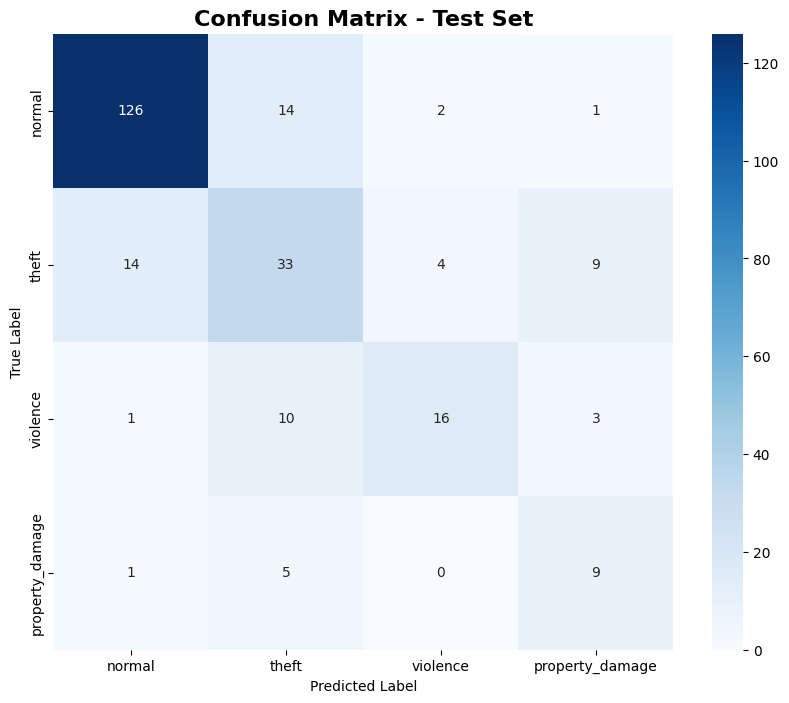


MISCLASSIFICATION ANALYSIS

Total Misclassifications: 64 out of 248

normal          → theft          :  14 times
theft           → normal         :  14 times
violence        → theft          :  10 times
theft           → property_damage:   9 times
property_damage → theft          :   5 times
theft           → violence       :   4 times
violence        → property_damage:   3 times
normal          → violence       :   2 times
property_damage → normal         :   1 times
violence        → normal         :   1 times
normal          → property_damage:   1 times


In [58]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define correct label names for your 4 classes
# This MUST match the order of label2id: {normal: 0, theft: 1, violence: 2, property_damage: 3}
eval_labels = ['normal', 'theft', 'violence', 'property_damage']
inv_label_map = {i: name for i, name in enumerate(eval_labels)}

print("\n" + "="*70)
print("COMPREHENSIVE TEST SET EVALUATION")
print("="*70)

# 2. Overall Metrics
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n📊 Overall Test Performance:")
print(f"   Test Accuracy: {test_acc*100:.2f}%")
print(f"   Test Loss: {test_loss:.4f}")

# 3. Get Predictions
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Fixed Classification Report (Using the 4 actual classes)
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT")
print("="*70)
print("\nPer-Class Metrics:")
print(classification_report(
    y_test, 
    y_pred, 
    target_names=eval_labels, # Fixed: now matches 4 classes
    digits=4
))

# 5. Confusion Matrix (Fixed labels)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=eval_labels,
    yticklabels=eval_labels
)
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. Misclassification Analysis
print("\n" + "="*70)
print("MISCLASSIFICATION ANALYSIS")
print("="*70 + "\n")

misclassified_indices = np.where(y_test != y_pred)[0]
print(f"Total Misclassifications: {len(misclassified_indices)} out of {len(y_test)}\n")

misclassification_pairs = {}
for idx in misclassified_indices:
    true_label = inv_label_map[y_test[idx]]
    pred_label = inv_label_map[y_pred[idx]]
    pair = (true_label, pred_label)
    misclassification_pairs[pair] = misclassification_pairs.get(pair, 0) + 1

# Sort and print
for (true_l, pred_l), count in sorted(misclassification_pairs.items(), key=lambda x: x[1], reverse=True):
    print(f"{true_l:15s} → {pred_l:15s}: {count:3d} times")